# **1. Business Understanding**

## E-Commerce Data Analysis (Olist)

## Business Problem

Olist is a Brazilian e-commerce platform with multiple sellers.

This project aims to analyze sales performance, customer behavior,
product performance, and delivery efficiency.

## Business Questions

sales & revenue

1. What is the total revenue trend over time?
2. Which products sell the most?
3. Which cities have the highest revenue?

customer

4. Apakah Delivery time mempengaruhi review score?
5. Which customers give the highest review ratings?

payments

6. Which payment method is used most often?

# **2. Data Understanding**

## Import Lib

In [82]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Connect db

In [83]:
conn = sqlite3.connect('olist.sqlite')

cursor = conn.cursor()

## Inspect Data

In [84]:
df_tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(df_tables)

                                 name
0   product_category_name_translation
1                             sellers
2                           customers
3                         geolocation
4                         order_items
5                      order_payments
6                       order_reviews
7                              orders
8                            products
9                     leads_qualified
10                       leads_closed


# **3. Data Preparation**

create dataset with join

In [110]:
query = """
SELECT
o.order_id,
o.order_purchase_timestamp,
c.customer_state,
oi.product_id,
oi.price,
p.product_category_name,
pay.payment_type,
o_r.review_score

FROM orders o

JOIN customers c
ON o.customer_id = c.customer_id

JOIN order_items oi
ON o.order_id = oi.order_id

JOIN products p
ON oi.product_id = p.product_id

JOIN order_payments pay
ON o.order_id = pay.order_id

JOIN order_reviews o_r
ON o.order_id = o_r.order_id
"""

df = pd.read_sql(query, conn)
df.head(3)

,order_id,order_purchase_timestamp,customer_state,product_id,price,product_category_name,payment_type,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,SP,87285b34884572647811a353c7ac498a,29.99,utilidades_domesticas,credit_card,4
1,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,SP,87285b34884572647811a353c7ac498a,29.99,utilidades_domesticas,voucher,4
2,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,SP,87285b34884572647811a353c7ac498a,29.99,utilidades_domesticas,voucher,4


# **4. Data Cleaning**

* missing values
* duplicate
* data type

In [86]:
df.info()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117601 entries, 0 to 117600
Data columns (total 7 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   order_id                  117601 non-null  object 
 1   order_purchase_timestamp  117601 non-null  object 
 2   customer_state            117601 non-null  object 
 3   product_id                117601 non-null  object 
 4   price                     117601 non-null  float64
 5   product_category_name     115903 non-null  object 
 6   payment_type              117601 non-null  object 
dtypes: float64(1), object(6)
memory usage: 6.3+ MB


order_id                       0
order_purchase_timestamp       0
customer_state                 0
product_id                     0
price                          0
product_category_name       1698
payment_type                   0
dtype: int64

perbandingan missing value dangan jumlah data

In [87]:
a =  1698 / 117601
a

0.014438652732544792

missing harus di tangani

In [88]:
df["product_category_name"] = df["product_category_name"].fillna("Unknown")

In [89]:
df.isnull().sum()

order_id                    0
order_purchase_timestamp    0
customer_state              0
product_id                  0
price                       0
product_category_name       0
payment_type                0
dtype: int64

ubah datatype

In [90]:
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

buat kolom baru (year, month)

In [91]:
df["year"] = df["order_purchase_timestamp"].dt.year
df["month"] = df["order_purchase_timestamp"].dt.month

# **5. EDA** 

# 1. berapa total revenue per tahun?

In [92]:
query = """
SELECT 
    strftime('%Y', o.order_purchase_timestamp) AS year,
    SUM(oi.price) AS total_revenue
FROM orders o 
JOIN order_items oi ON o.order_id = oi.order_id
GROUP BY year
ORDER BY total_revenue DESC;
"""

df_seller_revenue = pd.read_sql_query(query, conn)
df_seller_revenue.head()

,year,total_revenue
0,2018,7.386051e+06
1,2017,6.155807e+06
2,2016,4.978592e+04


month

In [142]:
query = """
SELECT 
    strftime('%M', o.order_purchase_timestamp) AS month,
    SUM(oi.price) AS total_revenue
FROM orders o 
JOIN order_items oi ON o.order_id = oi.order_id
GROUP BY month
ORDER BY month DESC
LIMIT 12;
"""

df_seller_revenue = pd.read_sql_query(query, conn)
df_seller_revenue.head()

,month,total_revenue
0,59,220248.64
1,58,244536.62
2,57,235549.74
3,56,220928.45
4,55,216801.41


# 2. produk mana yang paling banyak terjual?

In [93]:
query = """
SELECT 
    p.product_category_name,
    SUM(oi.order_item_id) AS quantity
FROM products p
JOIN order_items oi ON p.product_id = oi.product_id
GROUP BY p.product_category_name
ORDER BY quantity DESC;
"""

best_seller_product = pd.read_sql_query(query, conn)
best_seller_product.head(3)

,product_category_name,quantity
0,cama_mesa_banho,13665
1,moveis_decoracao,11540
2,beleza_saude,11081


# 3. kota mana yang punya revenue terbesar?

In [94]:
query = """
SELECT 
    c.customer_city,
    SUM(oi.price) AS total_revenue
FROM orders o 
JOIN order_items oi ON o.order_id = oi.order_id
JOIN customers c ON c.customer_id = o.customer_id
GROUP BY c.customer_city
ORDER BY total_revenue DESC;
"""

df_city_revenue = pd.read_sql_query(query, conn)
df_city_revenue.head()

,customer_city,total_revenue
0,sao paulo,1914924.54
1,rio de janeiro,992538.86
2,belo horizonte,355611.13
3,brasilia,301920.25
4,curitiba,211738.06


# 4. bagaimana distribusi harga product?

In [95]:
q = """SELECT 
        product_id,
        price,
        (price / order_item_id) AS price_per_product
        FROM order_items
        """

df_price_distribution = pd.read_sql_query(q, conn)
df_price_distribution.head()

,product_id,price,price_per_product
0,4244733e06e7ecb4970a6e2683c13e61,58.90,58.90
1,e5f2d52b802189ee658865ca93d83a8f,239.90,239.90
2,c777355d18b72b67abbeef9df44fd0fd,199.00,199.00
3,7634da152a4610f1595efa32f14722fc,12.99,12.99
4,ac6c3623068f30de03045865e4e10089,199.90,199.90


In [130]:
q = """SELECT
        AVG(price)
        FROM order_items
        """

avg_price = pd.read_sql_query(q, conn)
avg_price.head()

,AVG(price)
0,120.653739


# 5. apakah waktu delivery mempengaruhi kepuasan rating customer?

In [120]:
query = """
SELECT o.order_id,
        o.order_delivered_customer_date,
        o.order_delivered_carrier_date,
        o_r.review_score
FROM orders o 
JOIN order_reviews o_r ON o.order_id = o_r.order_id
order by o_r.review_score DESC;
"""

df_rating = pd.read_sql_query(query, conn)

# 1. Pastikan kolom menjadi format datetime
df_rating['order_delivered_customer_date'] = pd.to_datetime(df_rating['order_delivered_customer_date'])
df_rating['order_delivered_carrier_date'] = pd.to_datetime(df_rating['order_delivered_carrier_date'])

# 2. Hitung selisihnya (dalam satuan hari)
df_rating['delivery_time_days'] = (df_rating['order_delivered_customer_date'] - df_rating['order_delivered_carrier_date']).dt.days

# 3. Cek hasilnya
print(df_rating[['order_delivered_carrier_date', 'order_delivered_customer_date', 'delivery_time_days']].head())

  order_delivered_carrier_date order_delivered_customer_date  \
0          2018-08-08 13:50:00           2018-08-17 18:06:29   
1          2017-11-22 13:39:59           2017-12-02 00:28:42   
2          2018-02-14 19:46:34           2018-02-16 18:17:02   
3          2017-05-22 10:07:46           2017-05-26 12:55:51   
4          2017-08-10 19:45:24           2017-08-16 17:14:30   

   delivery_time_days  
0                 9.0  
1                 9.0  
2                 1.0  
3                 4.0  
4                 5.0  


# 6. payment method mana yang paling sering dipakai?

In [ ]:
query = """
SELECT payment_type,
        COUNT(payment_type) AS jumlah_transaksi
FROM order_payments
GROUP BY payment_type
ORDER BY jumlah_transaksi DESC;
"""

df_payment_method = pd.read_sql_query(query, conn)
df_payment_method

,payment_type,jumlah_transaksi
0,credit_card,76795
1,boleto,19784
2,voucher,5775
3,debit_card,1529
4,not_defined,3


# **6. Visualization**

## 1. Trend Revenue Per Year

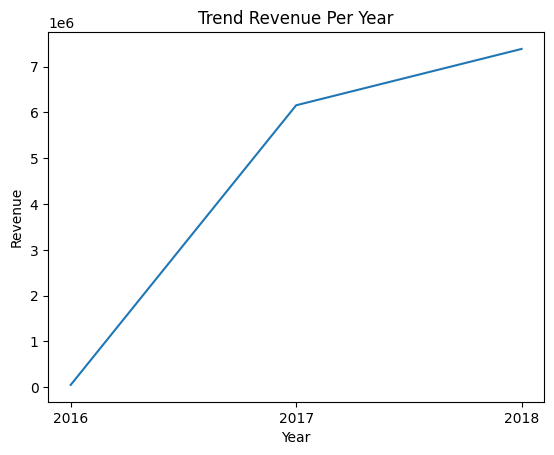

In [ ]:
trend_revenue_per_year = df_seller_revenue.sort_values(by='year', ascending=True)

sns.lineplot(data=trend_revenue_per_year,
             x='year',
             y='total_revenue')

plt.title('Trend Revenue Per Year')
plt.xlabel('Year')
plt.ylabel('Revenue')

plt.show()

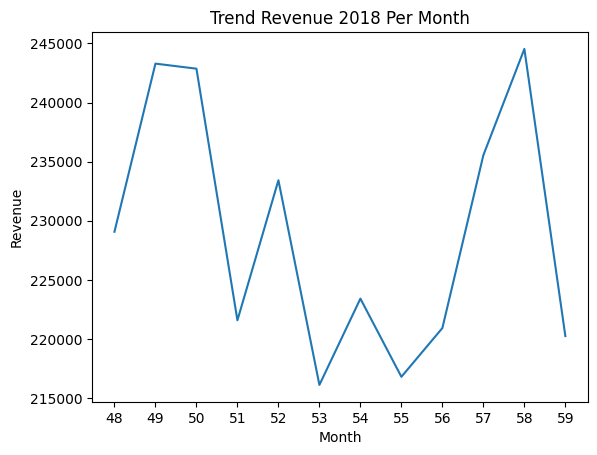

In [144]:
trend_revenue_per_year = df_seller_revenue.sort_values(by='month', ascending=True)

sns.lineplot(data=trend_revenue_per_year,
             x='month',
             y='total_revenue')

plt.title('Trend Revenue 2018 Per Month')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.show()

# 2. Best Seller Product

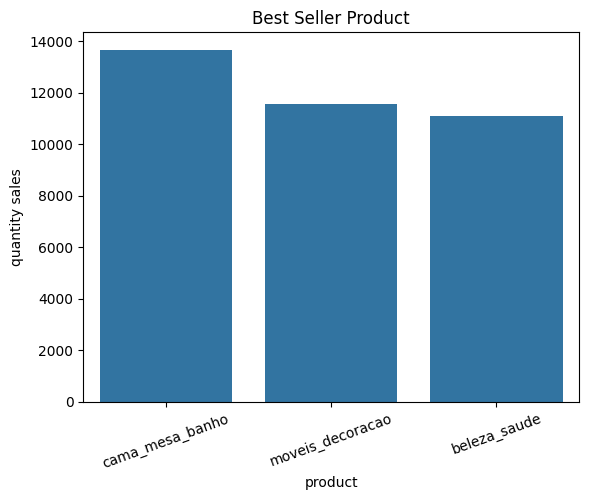

In [ ]:
top_3 = best_seller_product.sort_values(by='quantity', ascending=False).head(3)

sns.barplot(data=top_3,
            x='product_category_name',
            y='quantity')

plt.title('Best Seller Product')
plt.xlabel('product')
plt.ylabel('quantity sales')
plt.xticks(rotation=20)

plt.show()

# 3. Top City Revenue

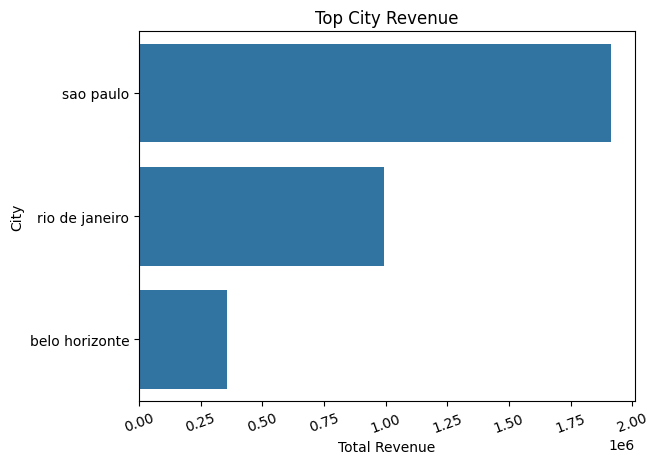

In [ ]:
top_city = df_city_revenue.sort_values(by='total_revenue', ascending=False).head(3)

sns.barplot(data=top_city,
            x='total_revenue',
            y='customer_city',
            orient='h')

plt.title('Top City Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('City')
plt.xticks(rotation=20)

plt.show()

# 4. distribusi harga product?

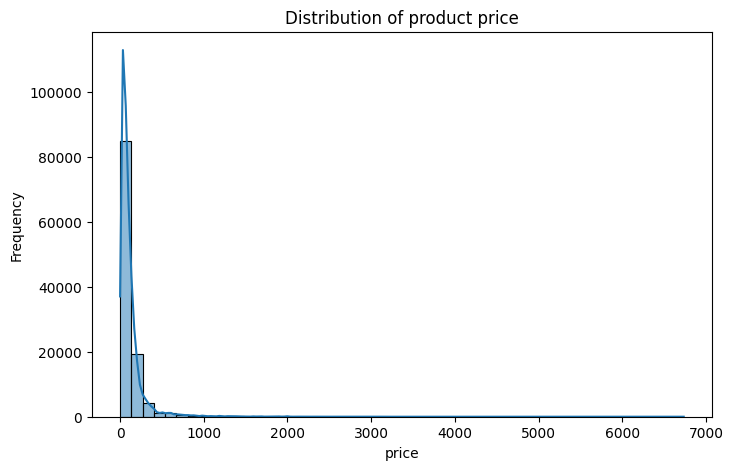

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(data=df_price_distribution['price'],
             bins=50,
             kde=True)

plt.title('Distribution of product price')
plt.xlabel('price')
plt.ylabel('Frequency')

plt.show()

# 5. apakah waktu delivery mempengaruhi kepuasan rating customer?

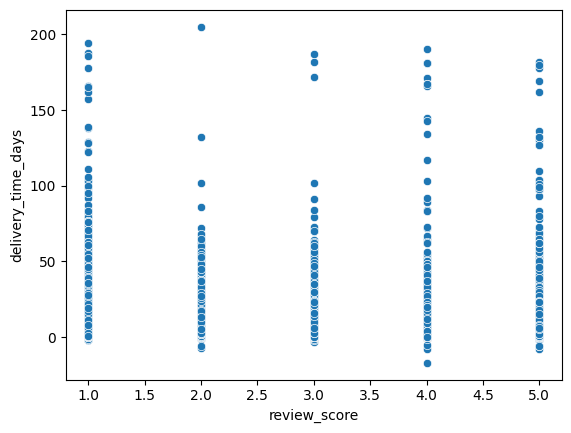

In [132]:
sns.scatterplot(data=df_rating,
                y='delivery_time_days',
                x='review_score')

plt.show()

# 6. payment method mana yang paling sering dipakai?

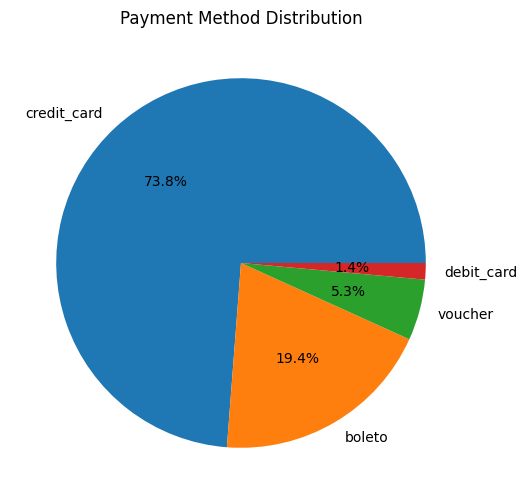

In [ ]:
payment_counts = df["payment_type"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(payment_counts, labels=payment_counts.index, autopct="%1.1f%%")

plt.title("Payment Method Distribution")
plt.show()

# **7. Insights**

1. Trend Revenue per tahun mengalamin kenaikan, kenaikan tertinggi ada pada tahun 2018 ini. Dan puncaknya pada akhir tahun mulai dari sep - des.
2. Top 3 product : cama_mesa_banho, moveis_decoracao, beleza_saude.
3. TOP 3 city : ao paulo, rio de janeiro, belo horizonte.
4. Harga product banyak yang dibawah 1000, dengan rata-rata 120.653739.
5. Tidak ada korelasi linear yang kuat antara hubungan delivery dengan review score.
6. 73.8% payment menggunakan credit card.

## **8. Recommendation**

1. Optimalisasi akhir tahun sep - des, buat promo, perbanyak quantity
2. perbanyak stok product-product best seller
3. Perbanyak stok dan promo pada toko kota-kota best city
4. Harga sudah baik dan cukup kompetitif
5. Delivery time tidak mempengaruhi customer review score. Artinya tidak masalah dan dapat memprioritaskan masalah lain.
6. Berikan promo jika customer payment 